In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

# --- CONFIGURATION ---
STRATEGY = 'fixed'  # Options: 'fixed' or 'sliding'
window_size = 100     # Subjects per window (sliding)
step_size = 100        # Subject step (sliding)
bin_size = 5          # Year width (fixed)

# --- 1. DATA LOADING & PREP ---
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')].copy()
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')
volumes = volumes.dropna(subset=['age_in_years', 'birth_year', 'sex', 'tiv'])

# --- 2. WINDOW DEFINITION (The "Pythonic" Way) ---
if STRATEGY == 'fixed':
    # Standard non-overlapping age bins
    bins = np.arange(15, 90, bin_size)
    volumes['bin'] = pd.cut(volumes['age_in_years'], bins=bins)
    # Filter out data outside defined bins
    volumes = volumes.dropna(subset=['bin'])

elif STRATEGY == 'sliding':
    # Create a unique metadata anchor sorted by age
    meta = (
        volumes[['session_id', 'age_in_years']]
        .drop_duplicates('session_id')
        .sort_values('age_in_years')
        .reset_index(drop=True)
    )
    
    # Generate mapping of session_id to windows
    # Note: One session will map to MULTIPLE windows due to overlap
    mappings = []
    session_ids = meta['session_id'].values
    
    for i in range(0, len(session_ids) - window_size + 1, step_size):
        subset_ids = session_ids[i : i + window_size]
        
        # Determine age boundaries for the label
        age_min = meta.iloc[i]['age_in_years']
        age_max = meta.iloc[i + window_size - 1]['age_in_years']
        label = f"W_{i//step_size:02d}_Age_{age_min:.1f}-{age_max:.1f}"
        
        for sid in subset_ids:
            mappings.append({'session_id': sid, 'bin': label})
    
    # Merge mappings back. This creates the necessary row duplication for overlaps.
    map_df = pd.DataFrame(mappings)
    volumes = volumes.merge(map_df, on='session_id')

# --- 3. ANALYSIS ---
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
results = []

# Grouping by 'bin' and 'region_label' handles all logic in one pass
grouped = volumes.groupby(['bin', 'region_label'], observed=True)

for (bin_label, roi), df_roi in tqdm(grouped, desc="Processing ROI per Window"):
    # Ensure sufficient sample size for the model
    if len(df_roi) < 20: 
        continue
        
    try:
        # GMV_ROI_1 ~ b1*birth_year + covariates
        model = smf.ols(
            'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years', 
            data=df_roi
        ).fit()
        
        for var in model.params.index:
            results.append({
                'bin': bin_label,
                'region_label': roi,
                'variable': var,
                'coef': model.params[var],
                't': model.tvalues[var],
                'p': model.pvalues[var],
                'n_subjects': df_roi['session_id'].nunique()
            })
    except:
        continue

# --- 4. POST-PROCESSING ---
coef_df = pd.DataFrame(results)

# Add Atlas names
coef_df = coef_df.merge(atlas_csv[['index', 'name']], left_on='region_label', right_on='index', how='left')
coef_df.rename(columns={'name': 'region_name'}, inplace=True)

# Multiple Comparison Correction (FDR) per window for 'birth_year'
final_rows = []
for label, group in coef_df.groupby('bin'):
    mask = group['variable'] == 'birth_year'
    if mask.any():
        _, fdr_p, _, _ = multipletests(group.loc[mask, 'p'], method='fdr_bh')
        group.loc[mask, 'fdr_p'] = fdr_p
    final_rows.append(group)

coef_df = pd.concat(final_rows)

# --- 5. SAVE ---
suffix = f"sliding_ws{window_size}_ss{step_size}" if STRATEGY == 'sliding' else f"fixed_bin{bin_size}"
coef_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_{suffix}.csv", index=False)

print("Analysis Complete.")

Processing ROI per Window: 100%|██████████| 6356/6356 [00:26<00:00, 241.27it/s] 


Analysis Complete.


Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                 -0.027
Method:                 Least Squares   F-statistic:                    0.7338
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.414
Time:                        16:42:22   Log-Likelihood:                -31.606
No. Observations:                  11   AIC:                             67.21
Df Residuals:                       9   BIC:                             68.01
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

/tmp/ipykernel_38012/947008959.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(lambda x: x.mid)
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


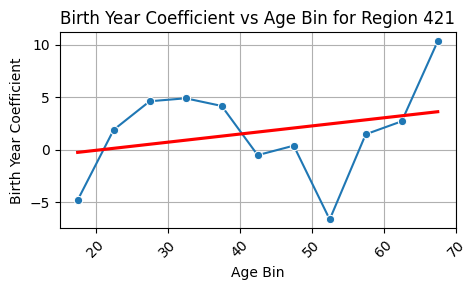

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

birth_year_coef_df = coef_df[coef_df['variable'] == 'birth_year']

# find the median age of each bin by min_age and max_age    
def extract_median_age(bin):
    if pd.isna(bin):
        return None
    # Extract age range from the bin label
    try:
        age_range = bin.split('_Age_')[1]
        age_min, age_max = map(float, age_range.split('-'))
        return (age_min + age_max) / 2
    except:
        return None

    
if STRATEGY == 'fixed':
# Function to convert the string "(20, 25]" into an Interval object
    birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(lambda x: x.mid)

elif STRATEGY == 'sliding':
    birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)
    

# plot coef vs age bin for a specific region
# all of them, list from 1 to 454
# roi_list = list(range(1, 455))
# roi_list = [421,422,448,449]
roi_list = [421]

for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    # calculate liner regression line
    if region_data.shape[0] < 2:
        print(f"Not enough data points for region {region_of_interest} to plot.")
        continue
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    print(f"Region {region_of_interest} - Coef vs Age Bin Regression Summary:")
    print(model.summary())

    # plot
    plt.figure(figsize=(5, 3))
    sns.lineplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        marker='o'
    )
    # add the regression line 
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        scatter=False,
        ci=None,
        line_kws={'color': 'red', 'label': 'Linear Fit'}
    )
    plt.title(f'Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

Processing file: /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss20.csv
Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.771
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.185
Time:                        16:40:56   Log-Likelihood:                -557.18
No. Observations:                 196   AIC:                             1118.
Df Residuals:                     194   BIC:                             1125.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t| 

/tmp/ipykernel_38012/2080913479.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)


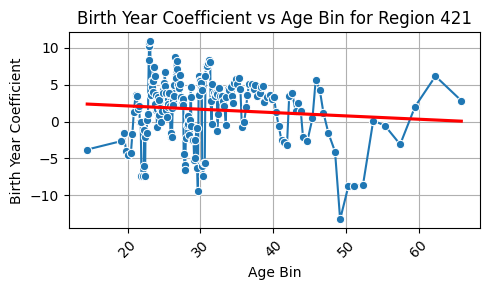

Processing file: /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss50.csv
Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8659
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.355
Time:                        16:40:57   Log-Likelihood:                -220.43
No. Observations:                  79   AIC:                             444.9
Df Residuals:                      77   BIC:                             449.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t| 

/tmp/ipykernel_38012/2080913479.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)


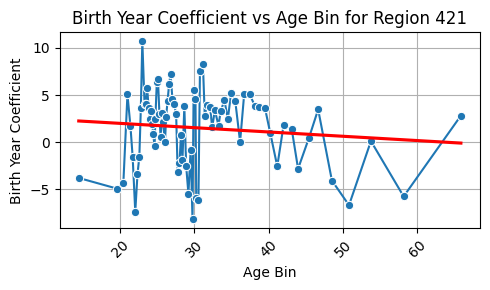

/tmp/ipykernel_38012/2080913479.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)


Processing file: /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss80.csv
Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.744
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.193
Time:                        16:40:57   Log-Likelihood:                -137.49
No. Observations:                  49   AIC:                             279.0
Df Residuals:                      47   BIC:                             282.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t| 

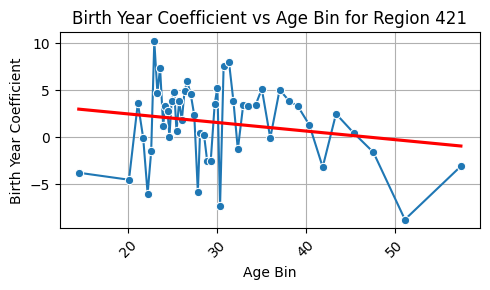

Processing file: /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss100.csv


/tmp/ipykernel_38012/2080913479.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)


Region 421 - Coef vs Age Bin Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   coef   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                   0.01482
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.904
Time:                        16:40:57   Log-Likelihood:                -109.71
No. Observations:                  40   AIC:                             223.4
Df Residuals:                      38   BIC:                             226.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
I

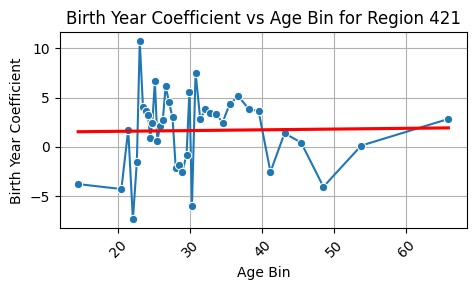

: 

: 

In [ ]:
def coef_trend(csv_path, roi_list):
    df = pd.read_csv(csv_path)
    birth_year_coef_df = df[df['variable'] == 'birth_year']
    birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['bin'].apply(extract_median_age)

    for region_of_interest in roi_list:
        region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
        # calculate liner regression line
        if region_data.shape[0] < 2:
            print(f"Not enough data points for region {region_of_interest} to plot.")
            continue
        model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
        print(f"Region {region_of_interest} - Coef vs Age Bin Regression Summary:")
        print(model.summary())

        # plot
        plt.figure(figsize=(5, 3))
        sns.lineplot(
            data=region_data,
            x='mid_age_bin',
            y='coef',
            marker='o'
        )
        # add the regression line 
        sns.regplot(
            data=region_data,
            x='mid_age_bin',
            y='coef',
            scatter=False,
            ci=None,
            line_kws={'color': 'red', 'label': 'Linear Fit'}
        )
        plt.title(f'Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
        plt.xlabel('Age Bin')
        plt.ylabel('Birth Year Coefficient')
        plt.xticks(rotation=45)
        plt.grid()
        plt.tight_layout()
        plt.show()


path_list = [
    "/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss20.csv",
    "/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss50.csv",
    "/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss80.csv",
    "/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_ws100_ss100.csv"
]
roi_list = [421]
for path in path_list:
    print(f"Processing file: {path}")
    coef_trend(path, roi_list)